In [32]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
import warnings
warnings.filterwarnings("ignore")

In [33]:
# 2. Load dataset
df = pd.read_csv("..\data\Superstore.csv", encoding='latin1')

In [34]:
# 3. Initial exploration
print("Shape of dataset:", df.shape)
print("\nDataset columns:\n", df.columns)
print("\nBasic Info:")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape of dataset: (9994, 21)

Dataset columns:
 Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   ob

In [35]:
# 4. Drop irrelevant or redundant columns if necessary
drop_cols = ['Country', 'Postal Code']  # Optional based on analysis
df.drop(columns=drop_cols, inplace=True)

In [36]:
# 5. Parse date fields
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [37]:
# 6. Drop rows with invalid dates
df.dropna(subset=['Order Date', 'Ship Date'], inplace=True)

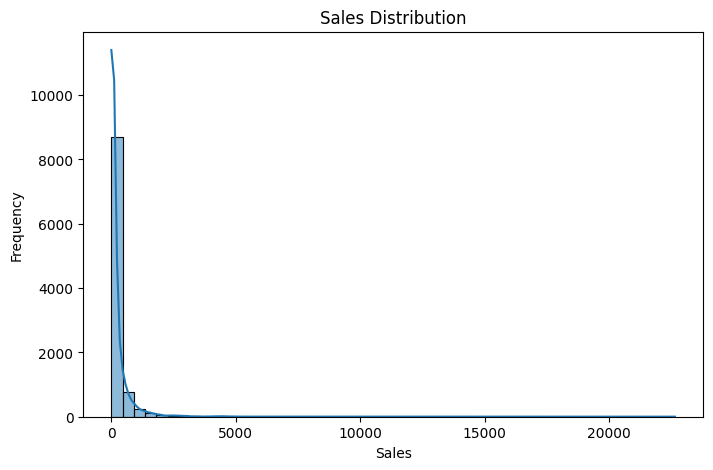

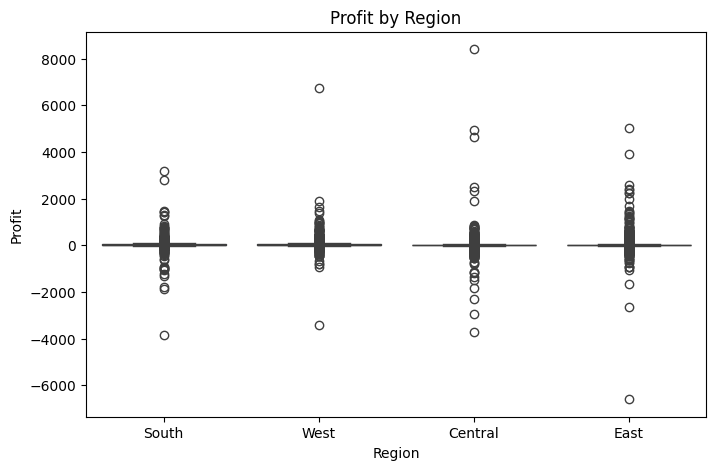

In [38]:
# 7. Univariate analysis
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Region', y='Profit', data=df)
plt.title("Profit by Region")
plt.show()

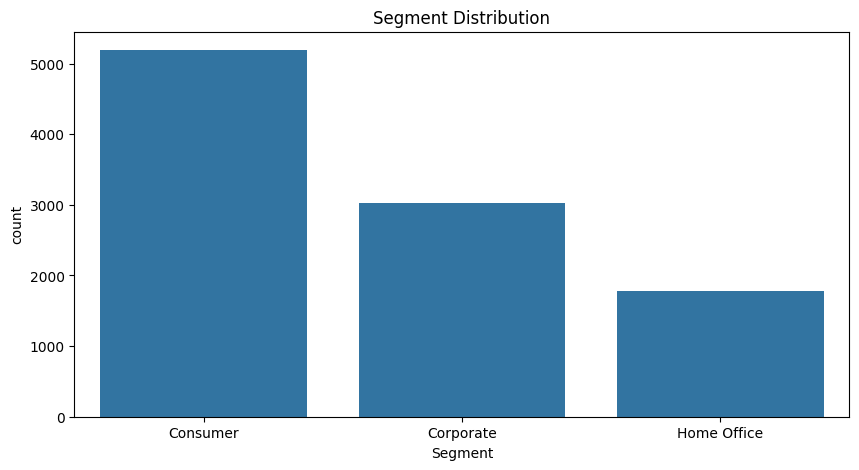

In [39]:
# 8. Categorical variable counts
plt.figure(figsize=(10, 5))
sns.countplot(x='Segment', data=df)
plt.title("Segment Distribution")
plt.show()

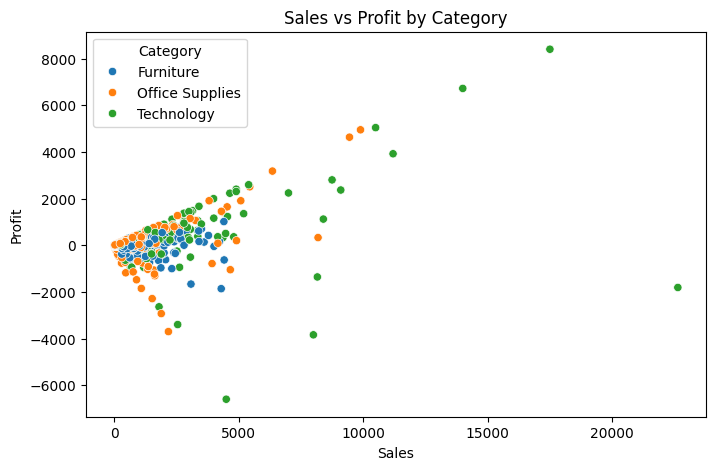

In [40]:
# 9. Bivariate analysis
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Category')
plt.title("Sales vs Profit by Category")
plt.show()


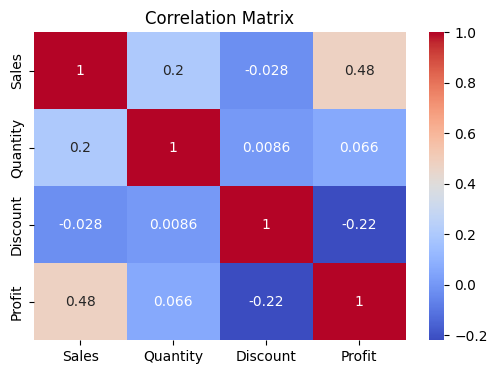

In [41]:
# 10. Correlation matrix
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

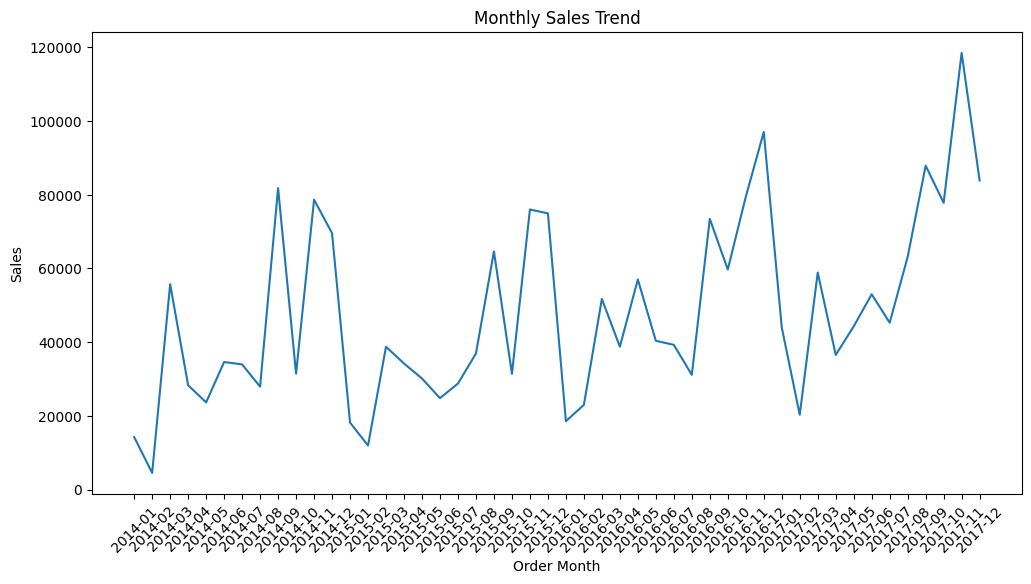

In [42]:
# 11. Time series trends
df['Order Month'] = df['Order Date'].dt.to_period("M").astype(str)
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Order Month', y='Sales')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.show()

In [43]:
# 12. Regional performance (render Plotly in browser)
import plotly.io as pio
pio.renderers.default = "browser"  # Open Plotly charts in browser
region_sales = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
fig = px.bar(region_sales, x='Region', y=['Sales', 'Profit'], barmode='group',
             title="Sales and Profit by Region")
fig.show()

In [44]:
# 13. Product category analysis
cat_sales = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
fig = px.pie(cat_sales, values='Sales', names='Category', title='Sales Share by Category')
fig.show()
    

In [45]:
# 14. Key Findings
print("\n✅ Key Insights:")
print("- Most sales and profits come from specific categories like Technology.")
print("- High discounts negatively affect profit margins.")
print("- Certain regions underperform in profit despite high sales.")
print("- Standard Class is the most used shipping method.")


✅ Key Insights:
- Most sales and profits come from specific categories like Technology.
- High discounts negatively affect profit margins.
- Certain regions underperform in profit despite high sales.
- Standard Class is the most used shipping method.
